In [1]:
"""This module implements an XRD pattern calculator."""

from __future__ import annotations
import torch
import json
import os
from math import asin, cos, degrees, pi, radians, sin
from typing import TYPE_CHECKING
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# Preliminary steps
# XRD wavelengths in angstroms
with open("atomic_scattering_params.json") as f:
	ATOMIC_SCATTERING_PARAMS = json.load(f)

import pandas as pd

len(list(ATOMIC_SCATTERING_PARAMS.keys()))

atom_names = {
	1: "H",
	2: "He",
	3: "Li",
	4: "Be",
	5: "B",
	6: "C",
	7: "N",
	8: "O",
	9: "F",
	10: "Ne",
	11: "Na",
	12: "Mg",
	13: "Al",
	14: "Si",
	15: "P",
	16: "S",
	17: "Cl",
	18: "Ar",
	19: "K",
	20: "Ca",
	21: "Sc",
	22: "Ti",
	23: "V",
	24: "Cr",
	25: "Mn",
	26: "Fe",
	27: "Co",
	28: "Ni",
	29: "Cu",
	30: "Zn",
	31: "Ga",
	32: "Ge",
	33: "As",
	34: "Se",
	35: "Br",
	36: "Kr",
	37: "Rb",
	38: "Sr",
	39: "Y",
	40: "Zr",
	41: "Nb",
	42: "Mo",
	43: "Tc",
	44: "Ru",
	45: "Rh",
	46: "Pd",
	47: "Ag",
	48: "Cd",
	49: "In",
	50: "Sn",
	51: "Sb",
	52: "Te",
	53: "I",
	54: "Xe",
	55: "Cs",
	56: "Ba",
	57: "La",
	58: "Ce",
	59: "Pr",
	60: "Nd",
	61: "Pm",
	62: "Sm",
	63: "Eu",
	64: "Gd",
	65: "Tb",
	66: "Dy",
	67: "Ho",
	68: "Er",
	69: "Tm",
	70: "Yb",
	71: "Lu",
	72: "Hf",
	73: "Ta",
	74: "W",
	75: "Re",
	76: "Os",
	77: "Ir",
	78: "Pt",
	79: "Au",
	80: "Hg",
	81: "Tl",
	82: "Pb",
	83: "Bi",
	84: "Po",
	85: "At",
	86: "Rn",
	87: "Fr",
	88: "Ra",
	89: "Ac",
	90: "Th",
	91: "Pa",
	92: "U",
	93: "Np",
	94: "Pu",
	95: "Am",
	96: "Cm",
	97: "Bk",
	98: "Cf"
}



In [184]:

atom_form_factor_constants = [
	[[0.202, 30.868], [0.244, 8.544], [0.082, 1.273], [0, 0]],
	[[0.091, 18.183], [0.181, 6.212], [0.11, 1.803], [0.036, 0.284]],
	[[1.611, 107.638], [1.246, 30.48], [0.326, 4.533], [0.099, 0.495]],
	[[1.25, 60.804], [1.334, 18.591], [0.36, 3.653], [0.106, 0.416]],
	[[0.945, 46.444], [1.312, 14.178], [0.419, 3.223], [0.116, 0.377]],
	[[0.731, 36.995], [1.195, 11.297], [0.456, 2.814], [0.125, 0.346]],
	[[0.572, 28.847], [1.043, 9.054], [0.465, 2.421], [0.131, 0.317]],
	[[0.455, 23.78], [0.917, 7.622], [0.472, 2.144], [0.138, 0.296]],
	[[0.387, 20.239], [0.811, 6.609], [0.475, 1.931], [0.146, 0.279]],
	[[0.303, 17.64], [0.72, 5.86], [0.475, 1.762], [0.153, 0.266]],
	[[2.241, 108.004], [1.333, 24.505], [0.907, 3.391], [0.286, 0.435]],
	[[2.268, 73.67], [1.803, 20.175], [0.839, 3.013], [0.289, 0.405]],
	[[2.276, 72.322], [2.428, 19.773], [0.858, 3.08], [0.317, 0.408]],
	[[2.129, 57.775], [2.533, 16.476], [0.835, 2.88], [0.322, 0.386]],
	[[1.888, 44.876], [2.469, 13.538], [0.805, 2.642], [0.32, 0.361]],
	[[1.659, 36.65], [2.386, 11.488], [0.79, 2.469], [0.321, 0.34]],
	[[1.452, 30.935], [2.292, 9.98], [0.787, 2.234], [0.322, 0.323]],
	[[1.274, 26.682], [2.19, 8.813], [0.793, 2.219], [0.326, 0.307]],
	[[3.951, 137.075], [2.545, 22.402], [1.98, 4.532], [0.482, 0.434]],
	[[4.47, 99.523], [2.971, 22.696], [1.97, 4.195], [0.482, 0.417]],
	[[3.966, 88.96], [2.917, 20.606], [1.925, 3.856], [0.48, 0.399]],
	[[3.565, 81.982], [2.818, 19.049], [1.893, 3.59], [0.483, 0.386]],
	[[3.245, 76.379], [2.698, 17.726], [1.86, 3.363], [0.486, 0.374]],
	[[2.307, 78.405], [2.334, 15.785], [1.823, 3.157], [0.49, 0.364]],
	[[2.747, 67.786], [2.456, 15.674], [1.792, 3.0], [0.498, 0.357]],
	[[2.544, 64.424], [2.343, 14.88], [1.759, 2.854], [0.506, 0.35]],
	[[2.367, 61.431], [2.236, 14.18], [1.724, 2.725], [0.515, 0.344]],
	[[2.21, 58.727], [2.134, 13.553], [1.689, 2.609], [0.524, 0.339]],
	[[1.579, 62.94], [1.82, 12.453], [1.658, 2.504], [0.532, 0.333]],
	[[1.942, 54.162], [1.95, 12.518], [1.619, 2.416], [0.543, 0.33]],
	[[2.321, 65.602], [2.486, 15.458], [1.688, 2.581], [0.599, 0.351]],
	[[2.447, 55.893], [2.702, 14.393], [1.616, 2.446], [0.601, 0.342]],
	[[2.399, 45.718], [2.79, 12.817], [1.529, 2.28], [0.594, 0.328]],
	[[2.298, 38.83], [2.854, 11.536], [1.456, 2.146], [0.59, 0.316]],
	[[2.166, 33.899], [2.904, 10.497], [1.395, 2.041], [0.589, 0.307]],
	[[2.034, 29.999], [2.927, 9.598], [1.342, 1.952], [0.589, 0.299]],
	[[4.776, 140.782], [3.859, 18.991], [2.234, 3.701], [0.868, 0.419]],
	[[5.848, 104.972], [4.003, 19.367], [2.342, 3.737], [0.88, 0.414]],
	[[4.129, 27.548], [3.012, 5.088], [1.179, 0.591], [0, 0]],
	[[4.105, 28.492], [3.144, 5.277], [1.229, 0.601], [0, 0]],
	[[4.237, 27.415], [3.105, 5.074], [1.234, 0.593], [0, 0]],
	[[3.12, 72.464], [3.906, 14.642], [2.361, 3.237], [0.85, 0.366]],
	[[4.318, 28.246], [3.27, 5.148], [1.287, 0.59], [0, 0]],
	[[4.358, 27.881], [3.298, 5.179], [1.323, 0.594], [0, 0]],
	[[4.431, 27.911], [3.343, 5.153], [1.345, 0.592], [0, 0]],
	[[4.436, 28.67], [3.454, 5.269], [1.383, 0.595], [0, 0]],
	[[2.036, 61.497], [3.272, 11.824], [2.511, 2.846], [0.837, 0.327]],
	[[2.574, 55.675], [3.259, 11.838], [2.547, 2.784], [0.838, 0.322]],
	[[3.153, 66.649], [3.557, 14.449], [2.818, 2.976], [0.884, 0.335]],
	[[3.45, 59.104], [3.735, 14.179], [2.118, 2.855], [0.877, 0.327]],
	[[3.564, 50.487], [3.844, 13.316], [2.687, 2.691], [0.864, 0.316]],
	[[4.785, 27.999], [3.688, 5.083], [1.5, 0.581], [0, 0]],
	[[3.473, 39.441], [4.06, 11.816], [2.522, 2.415], [0.84, 0.298]],
	[[3.366, 35.509], [4.147, 11.117], [2.443, 2.294], [0.829, 0.289]],
	[[6.062, 155.837], [5.986, 19.695], [3.303, 3.335], [1.096, 0.379]],
	[[7.821, 117.657], [6.004, 18.778], [3.28, 3.263], [1.103, 0.376]],
	[[4.94, 28.716], [3.968, 5.245], [1.663, 0.594], [0, 0]],
	[[5.007, 28.283], [3.98, 5.183], [1.678, 0.589], [0, 0]],
	[[5.085, 28.588], [4.043, 5.143], [1.684, 0.581], [0, 0]],
	[[5.151, 28.304], [4.075, 5.073], [1.683, 0.571], [0, 0]],
	[[5.201, 28.079], [4.094, 5.081], [1.719, 0.576], [0, 0]],
	[[5.255, 28.016], [4.113, 5.037], [1.743, 0.577], [0, 0]],
	[[5.267, 28.016], [4.113, 5.037], [1.743, 0.577], [0, 0]],
	[[5.225, 29.158], [4.314, 5.259], [1.827, 0.586], [0, 0]],
	[[5.272, 29.046], [4.347, 5.226], [1.844, 0.585], [0, 0]],
	[[5.332, 28.888], [4.37, 5.198], [1.863, 0.581], [0, 0]],
	[[5.376, 28.773], [4.403, 5.174], [1.884, 0.582], [0, 0]],
	[[5.436, 28.655], [4.437, 5.117], [1.891, 0.577], [0, 0]],
	[[5.441, 29.149], [4.51, 5.264], [1.956, 0.59], [0, 0]],
	[[5.529, 28.927], [4.533, 5.144], [1.945, 0.578], [0, 0]],
	[[5.553, 28.907], [4.58, 5.16], [1.969, 0.577], [0, 0]],
	[[5.588, 29.001], [4.619, 5.164], [1.997, 0.579], [0, 0]],
	[[5.659, 28.807], [4.63, 5.114], [2.014, 0.578], [0, 0]],
	[[5.709, 28.782], [4.677, 5.084], [2.019, 0.572], [0, 0]],
	[[5.695, 28.968], [4.74, 5.156], [2.064, 0.575], [0, 0]],
	[[5.75, 28.933], [4.773, 5.139], [2.079, 0.573], [0, 0]],
	[[5.754, 29.159], [4.851, 5.152], [2.096, 0.57], [0, 0]],
	[[5.803, 29.016], [4.87, 5.15], [2.127, 0.572], [0, 0]],
	[[2.388, 42.866], [4.226, 9.743], [2.689, 2.264], [1.255, 0.307]],
	[[2.682, 42.822], [4.241, 9.856], [2.755, 2.295], [1.27, 0.307]],
	[[5.932, 29.086], [4.972, 5.126], [2.195, 0.572], [0, 0]],
	[[3.51, 52.914], [4.552, 11.884], [3.154, 2.571], [1.359, 0.321]],
	[[3.841, 50.261], [4.679, 11.999], [3.192, 2.56], [1.363, 0.318]],
	[[6.07, 28.075], [4.997, 4.999], [2.232, 0.563], [0, 0]],
	[[6.133, 28.047], [5.031, 4.957], [2.239, 0.558], [0, 0]],
	[[4.078, 38.406], [4.978, 11.02], [3.096, 2.355], [1.326, 0.299]],
	[[6.201, 28.2], [5.121, 4.954], [2.275, 0.556], [0, 0]],
	[[6.215, 28.382], [5.17, 5.002], [2.316, 0.562], [0, 0]],
	[[6.278, 28.323], [5.195, 4.949], [2.321, 0.557], [0, 0]],
	[[6.264, 28.651], [5.263, 5.03], [2.367, 0.563], [0, 0]],
	[[6.306, 28.688], [5.303, 5.026], [2.386, 0.561], [0, 0]],
	[[6.767, 85.951], [6.729, 15.642], [4.014, 2.936], [1.561, 0.335]],
	[[6.323, 29.142], [5.414, 5.096], [2.453, 0.568], [0, 0]],
	[[6.415, 28.836], [5.419, 5.022], [2.449, 0.561], [0, 0]],
	[[6.462, 28.396], [5.469, 4.97], [2.471, 0.554], [0, 0]],
	[[6.46, 28.396], [5.469, 4.97], [2.471, 0.554], [0, 0]],
	[[6.502, 28.375], [5.478, 4.975], [2.51, 0.561], [0, 0]],
	[[6.548, 28.461], [5.526, 4.965], [2.52, 0.557], [0, 0]],
	[[6.58, 28.543], [5.572, 4.958], [2.538, 0.555], [0, 0]],
	[[6.61, 28.621], [5.615, 4.954], [2.553, 0.553], [0, 0]],
	[[6.638, 28.695], [5.655, 4.952], [2.566, 0.552], [0, 0]],
	[[6.665, 28.765], [5.692, 4.952], [2.577, 0.551], [0, 0]],
	[[6.69, 28.832], [5.727, 4.954], [2.587, 0.55], [0, 0]],
	[[6.713, 28.896], [5.759, 4.958], [2.596, 0.549], [0, 0]],
	[[6.735, 28.957], [5.789, 4.963], [2.604, 0.548], [0, 0]],
	[[6.756, 29.015], [5.817, 4.969], [2.611, 0.547], [0, 0]],
	[[6.776, 29.071], [5.843, 4.976], [2.618, 0.546], [0, 0]],
	[[6.795, 29.124], [5.867, 4.984], [2.624, 0.545], [0, 0]],
	[[6.813, 29.175], [5.89, 4.992], [2.63, 0.544], [0, 0]],
	[[6.831, 29.224], [5.912, 5.001], [2.635, 0.543], [0, 0]],
	[[6.848, 29.271], [5.932, 5.01], [2.64, 0.542], [0, 0]],
	[[6.864, 29.316], [5.951, 5.019], [2.645, 0.541], [0, 0]],
	[[6.88, 29.36], [5.969, 5.028], [2.649, 0.541], [0, 0]],
	[[6.895, 29.402], [5.986, 5.038], [2.653, 0.54], [0, 0]],
	[[6.909, 29.443], [6.002, 5.047], [2.657, 0.539], [0, 0]],
	[[6.923, 29.483], [6.017, 5.057], [2.661, 0.539], [0, 0]],
	[[6.936, 29.522], [6.031, 5.066], [2.664, 0.538], [0, 0]],
	[[6.949, 29.56], [6.044, 5.076], [2.667, 0.538], [0, 0]],
]



def get_cell_matrix(structure):
    angles = torch.tensor(structure[0], requires_grad=True)
    lengths = torch.tensor(structure[1], requires_grad=True)
    
    print(angles)
    
    angles_rad = angles * pi / 180

    a_vector = torch.tensor([1, 0, 0]) * lengths[0]
    b_vector = (torch.tensor([1,0,0]) * torch.cos(angles_rad[2]) + torch.tensor([0,1,0]) * torch.sin(angles_rad[2])) * lengths[1]
    c_vector = (torch.tensor([1,0,0]) * torch.cos(angles_rad[1]) + torch.tensor([0,1,0]) * ((torch.cos(angles_rad[0]) - torch.cos(angles_rad[1]) * torch.cos(angles_rad[2])) /  torch.sin(angles_rad[2])) + torch.tensor([0,0,1]) * torch.sqrt(1 - torch.square(torch.cos(angles_rad[1])) - torch.square((torch.cos(angles_rad[0]) - torch.cos(angles_rad[1]) * torch.cos(angles_rad[2])) / torch.sin(angles_rad[2]))) )* lengths[2]
    cell_matrix = torch.stack((a_vector,b_vector, c_vector))
    return cell_matrix


def collect_recip_latt_points(cell_matrix, q_max):
    
    print(cell_matrix)
    print(q_max)

    # Obtained from Bragg condition. Note that reciprocal lattice
    # vector length is 1 / d_hkl.
    recip_latt = torch.linalg.inv(cell_matrix).T

    max_r = q_max / (2 * pi)

    max_h = round(max_r / float(torch.linalg.norm(recip_latt[0])))
    max_k = round(max_r / float(torch.linalg.norm(recip_latt[1])))
    max_l = round(max_r / float(torch.linalg.norm(recip_latt[2])))

    hkl_pts = get_points_in_sphere(max_h, max_k, max_l)
    recip_pts = torch.mm(hkl_pts, recip_latt)
    recip_lengths = torch.linalg.norm(recip_pts, dim = 1)
    return hkl_pts, recip_lengths


def get_points_in_sphere(max_h, max_k, max_l):
	# TODO: Only do calculation for peaks that are within radius r of sphere
	# Right now, this calculates for peaks that are within rectangular prism that circumscribes sphere
	# Make a matrix the size of the reciprocal lattice
	hkl_ones_matrix = torch.ones((max_h*2 + 1, max_k * 2 + 1, max_l * 2 + 1))
	# Get the indices of every point in that lattice and flatten it into a [n, 3] list
	hkl_pts = torch.nonzero(hkl_ones_matrix) - torch.Tensor([max_h, 0, 0]) - torch.Tensor([0, max_k, 0]) - torch.Tensor([0, 0, max_l])
	# Remove the incident beam from the list of hkl points by taking out the point at the center of the list, [0,0,0]
	hkl_pts = hkl_pts[torch.arange(hkl_pts.size()[0]) != hkl_pts.size()[0] / 2 - 0.5]
	return hkl_pts

def get_fcoords_occus_zs_coeffs(structure):
    fcoords = torch.tensor(structure[2], requires_grad = True)
    occus = torch.tensor(structure[3], requires_grad = True)
    zs = torch.tensor(structure[4])

    coeffs = []

    # Collect the coefficients for each element in the structure into a torch tensor from the atom_form_factor_constants dictionary
    coeffs = torch.Tensor(atom_form_factor_constants)
    coeffs = coeffs[zs - 1]

    return fcoords, occus, zs, coeffs


def calc_atomic_scattering_factor(zs, recip_lengths, coeffs):
	#Add additional dimension to the r^2 list for each hkl
	squared_recip_lengths = torch.square(recip_lengths/2).unsqueeze(0)

	# Calculate the exponentiated component of the fitted atomic scattering factor
	extinct_exp = torch.exp(-coeffs[:, :, 1].unsqueeze(2) * squared_recip_lengths)
	
	# Calculate the whole of the fitted atomic scattering factor function
	fitted_factor = torch.sum(coeffs[:, :, 0].unsqueeze(2) * extinct_exp, axis = 1)

	# Calculate the full angle dependent component of the atomic scattering factor
	angle_fs = 41.78214 * squared_recip_lengths * fitted_factor

	# Calculate the atomic scattering factor for each hkl
	fs = zs.unsqueeze(1) - angle_fs

	return fs

def calc_lorentz_factor(recip_lengths, wavelength):
	# Calculate a theta list from r's
	theta = torch.asin(wavelength * recip_lengths / 2)

	# Calculate how the intensity of peaks are expected to tail off due to geometric constraints of experiments
	lorentz_factor = (1 + torch.square(torch.cos(2 * theta))) / (torch.square(torch.sin(theta)) * torch.cos(theta))

	"""Another way to calculate it without trig functions is
	x = wavelength * recip_lengths / 2
	lorentz_factor = -(4 * torch.square(torch.square(x)) + 4 * torch.square(x) - 2) / (torch.square(x) * torch.sqrt(1 - torch.square(x)))
	"""

	return lorentz_factor



def diffraction_calc(structure, q_max, wavelength):
	# default q_max should be 4 * pi / wavelength
	# Calculate the cell matrix
	cell_matrix = get_cell_matrix(structure)

	# Get all the hkl points that satisfy the chosen q_max and put them in a list
	# Also put the r of the lattice point in a different list
	hkl_pts, recip_lengths = collect_recip_latt_points(cell_matrix, q_max)

	# Collect all the information on the atoms
	fcoords, occus, zs, coeffs = get_fcoords_occus_zs_coeffs(structure)

	# Calculate the atom positions times each set of hkl indices
	g_dot_r = torch.mm(hkl_pts, fcoords.T)

	# Calculate the atomic scattering factors at each r (or angle)
	fs = calc_atomic_scattering_factor(zs, recip_lengths, coeffs)

	# Multiply the atomic scattering factors by the occupation of each site
	w_fs = torch.mm(occus, fs)

	# Calculate the complex phase and intensity of the scattering for each hkl
	f_hkl = torch.sum(w_fs.T * torch.exp(2j * pi * g_dot_r), axis = 1)

	# Calculate the real instensity for each hkl
	i_hkl = (f_hkl * torch.conj(f_hkl)).real

	# Calculate the lorentz factor based on the recip lengths
	lorentz_factor = calc_lorentz_factor(recip_lengths, wavelength)

	# Calculate two theta values from recip lengths and turn into degrees from rad
	# two_thetas = 2 * torch.asin(wavelength * recip_lengths / 2) * 180 / pi
	two_thetas = (360 / pi) * torch.asin(wavelength * recip_lengths / 2)

	#Calculate intensities from i_hkl and correction factor (lorentz_factor)
	intensities = i_hkl * lorentz_factor

	# Wrap the two thetas and intensities together
	pattern = torch.stack((two_thetas, intensities))

	# Remove all reflections which have unphysical angles/positions
	pattern = pattern.T
	filtered_pattern = pattern[~torch.any(pattern.isnan(), dim = 1)]

	return filtered_pattern



def bin_pattern_theta(diffraction_pattern, wavelength, q_min = 0.5, q_max = 8, num_steps = 256, fraction_gaussian = 0.5, fwhm = 1):
	# This function is written to work in degrees, it can be used for q instead, but fwhm should change, and the step size should be calculated differently

	# Calculate the theta range
	two_theta_min = np.arcsin((q_min * wavelength) / (4 * pi)) * 360 / pi
	two_theta_max = np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi
	
	# Calculate the width of each bin
    
	step_size = (two_theta_max - two_theta_min) / num_steps

	# Calculate prefactors for the pseudo-Voigt peak
	#ag = (2 / fwhm) * np.sqrt(np.log(2) / pi)
	ag = 0.9394372787 / fwhm
	#bg = (4 * np.log(2)) / (fwhm**2)
	bg = 2.77258872224 / (fwhm**2)

	# Make a tensor for the domain of the pattern
	pattern_domain = torch.arange(num_steps) * step_size + two_theta_min

	# Setup a domain for each peak in diffraction_pattern
	peaks = torch.ones((len(diffraction_pattern))) * pattern_domain.unsqueeze(1)

	# Calculate the gaussian component of the peak
	gaussian_peak = fraction_gaussian * ag * torch.exp(-bg * torch.square(peaks - diffraction_pattern[:, 0]))

	# Calculate the lorentzian component of the peak
	lorentz_peak = (1 - fraction_gaussian) * fwhm / (6.28318530718 * (torch.square(peaks - diffraction_pattern[:, 0]) + (fwhm/2)**2))

	# Calculate the combined peak
	combined_peak = diffraction_pattern[:, 1] * (gaussian_peak + lorentz_peak)

	# Sum over all peaks to get the binned pattern
	binned_pattern = torch.sum(combined_peak, axis = 1)
	return binned_pattern

def pymatgen_pattern(pattern):
	two_thetas = [0]
	temp_pattern = torch.Tensor([[0,0]])
	for i in range(pattern.size()[0]):
		if pattern[i, 1] > 0.001:
			ind = torch.where(torch.abs(torch.Tensor(two_thetas) - pattern[i, 0]) < 0.1)
			if ind[0].size()[0] > 0:
				temp_pattern[ind[0]][0][1] = temp_pattern[ind[0]][0][1] + pattern[i][1]
			else:
				temp_pattern = torch.cat((temp_pattern, pattern[i].unsqueeze(0)))
				two_thetas.append(pattern[i][0])
	print(temp_pattern)


In [185]:
def diffraction_loss(structure_gen, structure_ref, wavelength = 1.54184, q_max = 4):
    ref_pattern = diffraction_calc(structure_ref, q_max, wavelength)
    binned_ref_pattern = bin_pattern_theta(ref_pattern, wavelength, q_max = q_max)
    gen_pattern = diffraction_calc(structure_gen, q_max, wavelength)
    binned_gen_pattern = bin_pattern_theta(gen_pattern, wavelength, q_max = q_max)

    print(binned_ref_pattern.shape)
    print(binned_gen_pattern.shape)
    
    binned_ref_pattern = binned_ref_pattern.unsqueeze(0)
    binned_gen_pattern = binned_gen_pattern.unsqueeze(0)
    
    loss = -1*F.cosine_similarity(binned_ref_pattern, binned_gen_pattern)
    
    return loss

In [186]:
angles_ref = [90.0,90.0,90.0]
lengths_ref = [4.0,4.0,4.0]
atom_positions_ref = [[0,0,0],[.5,.5,.5],[0.75,0.75,0.75]]
atom_types_ref = [[0.25,0.75],[0.25,0.75],[0.5,0.5]]
zs_ref = [1,2]

angles_gen = [90.0,90.0,90.0]
lengths_gen = [4.0,4.0,4.0]
atom_positions_gen = [[0,0,0],[0.5,0.5,0.5]]
atom_types_gen = [[0.25,0.75],[0.25,0.75]]
zs_gen = [1,2]

structure_ref = [angles_ref, lengths_ref, atom_positions_ref, atom_types_ref, zs_ref]
structure_gen = [angles_gen, lengths_gen, atom_positions_gen, atom_types_gen, zs_gen]

diffraction_loss(structure_gen, structure_ref)

tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
torch.Size([256])
torch.Size([256])


tensor([-0.9748], grad_fn=<MulBackward0>)

tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4


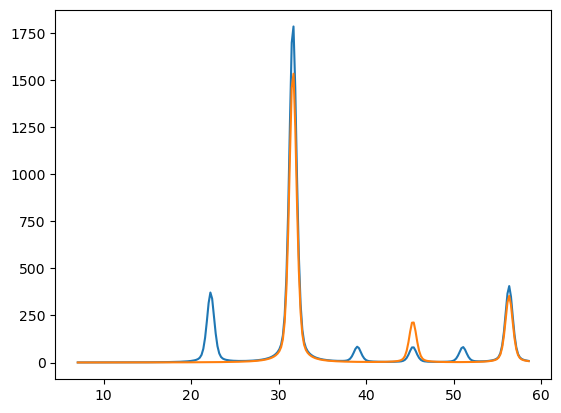

In [187]:
q_min = 0.5
num_steps = 256
wavelength = 1.54184
q_max = 4

ref_pattern = diffraction_calc(structure_ref, q_max, wavelength)
binned_ref_pattern = bin_pattern_theta(ref_pattern, wavelength, q_max = q_max)
gen_pattern = diffraction_calc(structure_gen, q_max, wavelength)
binned_gen_pattern = bin_pattern_theta(gen_pattern, wavelength, q_max = q_max)


two_theta_min = np.arcsin((q_min * wavelength) / (4 * pi)) * 360 / pi
two_theta_max = np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi
step_size = (two_theta_max - two_theta_min) / num_steps
domain = np.arange(len(binned_ref_pattern)) * step_size + two_theta_min
plt.plot(domain, binned_ref_pattern.detach().numpy())
plt.plot(domain, binned_gen_pattern.detach().numpy())
plt.savefig("diffraction_loss.png")

In [188]:
def pymatgen_pattern(pattern):
    two_thetas = [0]
    temp_pattern = torch.Tensor([[0,0]])
    for i in range(pattern.size()[0]):
        if pattern[i, 1] > 0.001:
            ind = torch.where(torch.abs(torch.Tensor(two_thetas) - pattern[i, 0]) < 0.1)
            if ind[0].size()[0] > 0:
                temp_pattern[ind[0]][0][1] = temp_pattern[ind[0]][0][1] + pattern[i][1]
            else:
                temp_pattern = torch.cat((temp_pattern, pattern[i].unsqueeze(0)))
                two_thetas.append(pattern[i][0])
    return(temp_pattern)

In [189]:
angles_ref = [90.0,90.0,90.0]
lengths_ref = [4.0,4.0,4.0]
atom_positions_ref = [[0,0,0],[.5,.5,.5]]
atom_types_ref = [[0.25,0.75],[0.25,0.75]]
zs_ref = [1,2]

angles_gen = [90.0,90.0,90.0]
lengths_gen = [4.0,4.0,4.0]
atom_positions_gen = [[0,0,0],[0.5,0.5,0.5]]
atom_types_gen = [[0.25,0.75],[0.25,0.75]]
zs_gen = [1,2]

structure_ref = [angles_ref, lengths_ref, atom_positions_ref, atom_types_ref, zs_ref]
structure_gen = [angles_gen, lengths_gen, atom_positions_gen, atom_types_gen, zs_gen]

diffraction_loss(structure_gen, structure_ref)

tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
torch.Size([256])
torch.Size([256])


tensor([-1.], grad_fn=<MulBackward0>)

In [190]:
from pymatgen.core import Lattice, Structure, Composition
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import matplotlib.pyplot as plt

angles_ref = [90.0, 90.0, 90.0]
lengths_ref = [4.0, 4.0, 4.0]
atom_positions_ref = [[0, 0, 0], [0.5, 0.5, 0.5]]
atom_types_ref = [[0.25, 0.75], [0.25, 0.75]]  # Fractional occupation
zs_ref = [1, 2]

# Create the lattice and the structure
lattice = Lattice.from_parameters(a=lengths_ref[0], b=lengths_ref[1], c=lengths_ref[2],
                                  alpha=angles_ref[0], beta=angles_ref[1], gamma=angles_ref[2])
structure = Structure(lattice, [], [])

# Add the atoms with fractional occupation
for pos, types, z in zip(atom_positions_ref, atom_types_ref, zs_ref):
    comp = {str(z): occ for z, occ in zip(zs_ref, types)}
    structure.append(Composition(comp), pos, coords_are_cartesian=False)

# Calculate the XRD pattern
xrd_calculator = XRDCalculator()
pattern = xrd_calculator.get_pattern(structure)

In [191]:
ref_pattern

tensor([[1.2937e+02, 2.5438e+00],
        [1.1430e+02, 1.8608e-01],
        [1.0971e+02, 5.9600e-01],
        [1.1430e+02, 1.8608e-01],
        [1.2937e+02, 2.5438e+00],
        [1.2937e+02, 2.5438e+00],
        [1.0524e+02, 2.1086e-01],
        [9.2296e+01, 9.1095e-01],
        [8.8038e+01, 3.5767e-01],
        [9.2296e+01, 4.2151e+00],
        [1.0524e+02, 2.1086e-01],
        [1.2937e+02, 5.5294e-01],
        [1.1430e+02, 1.8608e-01],
        [9.2296e+01, 9.1095e-01],
        [7.9466e+01, 5.4603e-01],
        [7.5102e+01, 9.6594e+00],
        [7.9466e+01, 5.4603e-01],
        [9.2296e+01, 9.1095e-01],
        [1.1430e+02, 1.8608e-01],
        [1.0971e+02, 5.9600e-01],
        [8.8038e+01, 3.5767e-01],
        [7.5102e+01, 9.6594e+00],
        [7.0647e+01, 9.3809e-01],
        [7.5102e+01, 2.0419e+00],
        [8.8038e+01, 3.5767e-01],
        [1.0971e+02, 2.7470e+00],
        [1.1430e+02, 1.8608e-01],
        [9.2296e+01, 4.2151e+00],
        [7.9466e+01, 5.4603e-01],
        [7.510

In [192]:
combined = torch.tensor(np.column_stack((np.array(pattern.x), np.array(pattern.y))))

In [193]:
pymatgen_adjusted = pymatgen_pattern(combined)

In [194]:
pymatgen_adjusted

tensor([[  0.0000,   0.0000],
        [ 31.6335, 100.0000],
        [ 45.3446,  14.0288],
        [ 56.3401,  22.7945],
        [ 66.0661,   5.5855],
        [ 75.1018,   6.2610],
        [ 83.7698,   1.3120]], dtype=torch.float64)

tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4


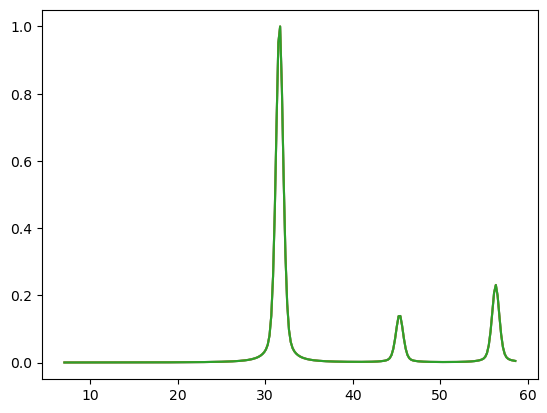

In [195]:
q_min = 0.5
num_steps = 256
wavelength = 1.54184
q_max = 4

ref_pattern = diffraction_calc(structure_ref, q_max, wavelength)
binned_ref_pattern = bin_pattern_theta(ref_pattern, wavelength, q_max = q_max)
gen_pattern = diffraction_calc(structure_gen, q_max, wavelength)
binned_gen_pattern = bin_pattern_theta(gen_pattern, wavelength, q_max = q_max)

binned_pymatgen_adjusted = bin_pattern_theta(pymatgen_adjusted, wavelength, q_max = q_max)

#normalize all
binned_pymatgen_adjusted /= torch.max(binned_pymatgen_adjusted)
binned_ref_pattern /= torch.max(binned_ref_pattern)
binned_gen_pattern /= torch.max(binned_gen_pattern)

two_theta_min = np.arcsin((q_min * wavelength) / (4 * pi)) * 360 / pi
two_theta_max = np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi
step_size = (two_theta_max - two_theta_min) / num_steps
domain = np.arange(len(binned_ref_pattern)) * step_size + two_theta_min
plt.plot(domain, binned_ref_pattern.detach().numpy())
plt.plot(domain, binned_gen_pattern.detach().numpy())
plt.plot(domain, binned_pymatgen_adjusted.detach().numpy())
plt.savefig("diffraction_loss.png")

In [196]:
from torch.utils.tensorboard import SummaryWriter
import torch

In [197]:
import torch
import torch.nn as nn
import numpy as np
from math import pi

In [198]:
import torch

# Convert the lists to tensors
angles_ref_tensor = torch.tensor(angles_ref)
lengths_ref_tensor = torch.tensor(lengths_ref)
atom_positions_ref_tensor = torch.tensor(atom_positions_ref)
atom_types_ref_tensor = torch.tensor(atom_types_ref)

# Check the tensors
print("Angles Tensor:", angles_ref_tensor)
print("Lengths Tensor:", lengths_ref_tensor)
print("Atom Positions Tensor:", atom_positions_ref_tensor)
print("Atom Types Tensor:", atom_types_ref_tensor)

Angles Tensor: tensor([90., 90., 90.])
Lengths Tensor: tensor([4., 4., 4.])
Atom Positions Tensor: tensor([[0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000]])
Atom Types Tensor: tensor([[0.2500, 0.7500],
        [0.2500, 0.7500]])


In [199]:
class DiffractionModule(nn.Module):
    def __init__(self, angles_ref, lengths_ref, atom_positions_ref, atom_types_ref, q_max, wavelength):
        super(DiffractionModule, self).__init__()
        
        angles_ref_tensor = torch.tensor(angles_ref)
        lengths_ref_tensor = torch.tensor(lengths_ref)
        atom_positions_ref_tensor = torch.tensor(atom_positions_ref)
        atom_types_ref_tensor = torch.tensor(atom_types_ref)
        
        self.angles_ref = torch.nn.Parameter(angles_ref_tensor)
        
        print(self.angles_ref)
        self.lengths_ref = torch.nn.Parameter(lengths_ref_tensor)
        self.atom_positions_ref = torch.nn.Parameter(atom_positions_ref_tensor)
        self.atom_types_ref = torch.nn.Parameter(atom_types_ref_tensor)
    
        self.q_max = q_max
        self.wavelength = wavelength
    
    def forward(self, zs_ref): 
        print(self.q_max)
        print(self.wavelength)
        
        structure_ref = [self.angles_ref, self.lengths_ref, self.atom_positions_ref, self.atom_types_ref, zs_ref]
        
        diffraction_pattern = diffraction_calc(structure_ref, self.q_max, self.wavelength)
        return diffraction_pattern
    

In [200]:
DiffractionModel = DiffractionModule(angles_ref, lengths_ref, atom_positions_ref, atom_types_ref, q_max = 4, wavelength = 1.54184)

Parameter containing:
tensor([90., 90., 90.], requires_grad=True)


In [201]:
angles_ref = [90.0,90.0,90.0]
lengths_ref = [4.0,4.0,4.0]
atom_positions_ref = [[0.0,0.0,0.0],[.5,.5,.5]]
atom_types_ref = [[0.25,0.75],[0.25,0.75]]
zs_ref = [1,2]

angles_gen = [90.0,90.0,90.0]
lengths_gen = [4.0,4.0,4.0]
atom_positions_gen = [[0.0,0.0,0.0],[0.5,0.5,0.5]]
atom_types_gen = [[0.25,0.75],[0.25,0.75]]
zs_gen = [1,2]

structure_ref = [angles_ref, lengths_ref, atom_positions_ref, atom_types_ref, zs_ref]
structure_gen = [angles_gen, lengths_gen, atom_positions_gen, atom_types_gen, zs_gen]

In [214]:
DiffractionModel.zero_grad() # Zero out gradients in the model

In [215]:
output = DiffractionModel(zs_gen)

4
1.54184
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4


/state/partition1/slurm_tmp/24454912.0.0/ipykernel_3777602/2965512682.py:125: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  angles = torch.tensor(structure[0], requires_grad=True)
/state/partition1/slurm_tmp/24454912.0.0/ipykernel_3777602/2965512682.py:126: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lengths = torch.tensor(structure[1], requires_grad=True)
/state/partition1/slurm_tmp/24454912.0.0/ipykernel_3777602/2965512682.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fcoords = torch.tensor(structure[2], requires_grad = True)


In [216]:
output

tensor([[1.2937e+02, 1.3672e+00],
        [1.1430e+02, 6.1704e-13],
        [1.0971e+02, 1.4755e+00],
        [1.1430e+02, 1.5985e-13],
        [1.2937e+02, 1.3672e+00],
        [1.2937e+02, 1.3672e+00],
        [1.0524e+02, 6.9895e-13],
        [9.2296e+01, 2.2613e+00],
        [8.8038e+01, 3.0464e-13],
        [9.2296e+01, 2.2613e+00],
        [1.0524e+02, 2.2570e-16],
        [1.2937e+02, 1.3672e+00],
        [1.1430e+02, 6.1704e-13],
        [9.2296e+01, 2.2613e+00],
        [7.9466e+01, 4.5915e-13],
        [7.5102e+01, 5.1459e+00],
        [7.9466e+01, 5.7231e-16],
        [9.2296e+01, 2.2613e+00],
        [1.1430e+02, 2.6772e-15],
        [1.0971e+02, 1.4755e+00],
        [8.8038e+01, 3.0464e-13],
        [7.5102e+01, 5.1459e+00],
        [7.0647e+01, 9.6274e-16],
        [7.5102e+01, 5.1459e+00],
        [8.8038e+01, 5.1020e-15],
        [1.0971e+02, 1.4755e+00],
        [1.1430e+02, 1.5985e-13],
        [9.2296e+01, 2.2613e+00],
        [7.9466e+01, 5.7231e-16],
        [7.510

In [217]:
target = DiffractionModel(zs_ref)
loss = diffraction_loss(structure_gen, structure_ref) 

4
1.54184
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
tensor([90., 90., 90.], requires_grad=True)
tensor([[ 4.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7485e-07,  4.0000e+00,  0.0000e+00],
        [-1.7485e-07, -1.7485e-07,  4.0000e+00]], grad_fn=<StackBackward>)
4
torch.Size([256])
torch.Size([256])


/state/partition1/slurm_tmp/24454912.0.0/ipykernel_3777602/2965512682.py:125: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  angles = torch.tensor(structure[0], requires_grad=True)
/state/partition1/slurm_tmp/24454912.0.0/ipykernel_3777602/2965512682.py:126: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lengths = torch.tensor(structure[1], requires_grad=True)
/state/partition1/slurm_tmp/24454912.0.0/ipykernel_3777602/2965512682.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fcoords = torch.tensor(structure[2], requires_grad = True)


In [218]:
loss

tensor([-1.], grad_fn=<MulBackward0>)

In [219]:
loss.backward()

In [221]:
for param in DiffractionModel.parameters():
    print(param)
    try: 
        print(param.grad.data)
    except: 
        print("oops")
    

Parameter containing:
tensor([90., 90., 90.], requires_grad=True)
oops
Parameter containing:
tensor([4., 4., 4.], requires_grad=True)
oops
Parameter containing:
tensor([[0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000]], requires_grad=True)
oops
Parameter containing:
tensor([[0.2500, 0.7500],
        [0.2500, 0.7500]], requires_grad=True)
oops


In [ ]:
for param in model.parameters():
    param.data -= learning_rate * param.grad.data